In [9]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiLineString
from shapely import affinity
from dataclasses import dataclass, asdict

@dataclass
class Swath:
    start: tuple[float, float]
    end: tuple[float, float]

In [10]:
def get_optimal_angle(polygon: Polygon) -> float:
    """Finds the angle of the longest edge to minimize turns."""
    rect = polygon.minimum_rotated_rectangle
    coords = list(rect.exterior.coords)
    p1, p2, p3 = coords[0], coords[1], coords[2]
    len1, len2 = math.dist(p1, p2), math.dist(p2, p3)
    
    if len1 > len2:
        dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    else:
        dx, dy = p3[0] - p2[0], p3[1] - p2[1]
    return math.degrees(math.atan2(dy, dx))

def generate_optimized_paint_lines(exterior, holes, brush_diameter):
    """Generates paint strokes aligned to the longest axis."""
    brush_radius = brush_diameter / 2.0
    canvas = Polygon(exterior, holes)
    safe_zone = canvas.buffer(-brush_radius)
    
    if safe_zone.is_empty:
        return canvas, safe_zone, []

    optimal_angle = get_optimal_angle(safe_zone)
    centroid = safe_zone.centroid
    flat_safe_zone = affinity.rotate(safe_zone, -optimal_angle, origin=centroid)
    
    minx, miny, maxx, maxy = flat_safe_zone.bounds
    swaths = []
    y_coords = np.arange(miny + brush_radius, maxy, brush_diameter)
    
    for y in y_coords:
        sweep_line = LineString([(minx - 1, y), (maxx + 1, y)])
        clipped_lines = sweep_line.intersection(flat_safe_zone)
        
        if clipped_lines.is_empty:
            continue
            
        lines_to_process = [clipped_lines] if isinstance(clipped_lines, LineString) else list(clipped_lines.geoms)
        
        for line in lines_to_process:
            original_angle_line = affinity.rotate(line, optimal_angle, origin=centroid)
            coords = list(original_angle_line.coords)
            swaths.append(Swath(start=coords[0], end=coords[-1]))
            
    return canvas, safe_zone, swaths

def calculate_start_coordinate(safe_zone, direction: str) -> list[float]:
    """Translates 'North', 'South', etc. into an exact starting coordinate."""
    if safe_zone.is_empty:
        return [0.0, 0.0]
    minx, miny, maxx, maxy = safe_zone.bounds
    midx, midy = (minx + maxx) / 2.0, (miny + maxy) / 2.0
    
    direction = direction.lower()
    if direction == "north": return [midx, maxy]
    elif direction == "south": return [midx, miny]
    elif direction == "east": return [maxx, midy]
    elif direction == "west": return [minx, midy]
    return [minx, miny]

In [11]:
# 1. Load the user's configuration file
with open('canvas.json', 'r') as file:
    user_data = json.load(file)

# 2. Extract variables
u_brush = user_data['brush_diameter']
u_exterior = user_data['exterior_coordinates']
u_holes = user_data['hole_coordinates']
u_direction = user_data.get('entry_direction', 'West')

# 3. Run the Geometry Engine
canvas_poly, safe_poly, paint_strokes = generate_optimized_paint_lines(u_exterior, u_holes, u_brush)

print(f"Success! Generated {len(paint_strokes)} optimal strokes.")
print(f"Robot will approach from the general {u_direction.upper()} direction. Router will determine exact start point.")

Success! Generated 12 optimal strokes.
Robot will approach from the general WEST direction. Router will determine exact start point.


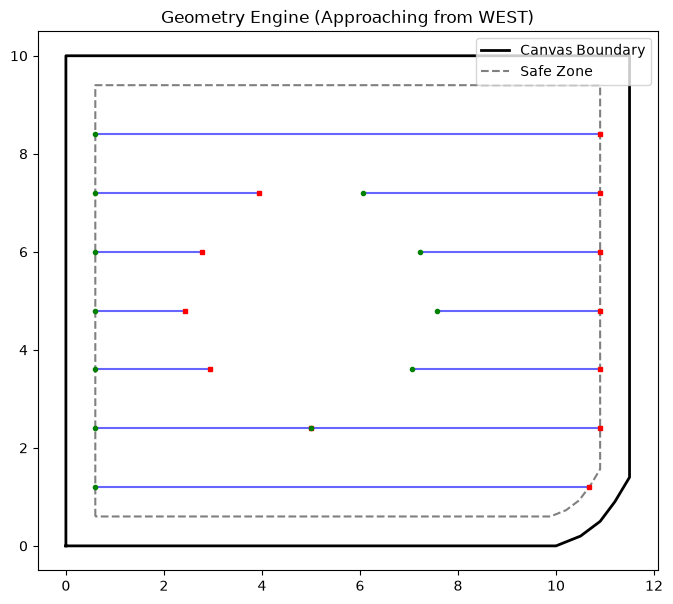

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot Canvas and Safe Zone
ax.plot(*canvas_poly.exterior.xy, color='black', linewidth=2, label='Canvas Boundary')
if not safe_poly.is_empty:
    ax.plot(*safe_poly.exterior.xy, color='gray', linestyle='--', label='Safe Zone')

# Plot the generated strokes
for s in paint_strokes:
    ax.plot([s.start[0], s.end[0]], [s.start[1], s.end[1]], color='blue', alpha=0.6)
    ax.plot(s.start[0], s.start[1], 'go', markersize=3)
    ax.plot(s.end[0], s.end[1], 'rs', markersize=3)

# Add a text label indicating where the robot comes from
ax.set_title(f"Geometry Engine (Approaching from {u_direction.upper()})")
ax.set_aspect('equal')
plt.legend(loc='upper right')
plt.show()

In [13]:
export_data = {
    "entry_direction": u_direction,
    "swaths": [asdict(swath) for swath in paint_strokes]
}

with open('generated_swaths.json', 'w') as f:
    json.dump(export_data, f, indent=4)
    
print("Export complete! 'generated_swaths.json' is ready for the Routing Engine.")

Export complete! 'generated_swaths.json' is ready for the Routing Engine.
